In [3]:
import numpy as np 
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vishwakarmaprankit/electronics/Electronics.json
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/Home_and_Kitchen_5.json.gz
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/Video_Games.json.gz
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/Cell_Phones_and_Accessories.json.gz
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/__results__.html
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/Automotive.json.gz
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/__notebook__.ipynb
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/__output__.json
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/Pet_Supplies.json.gz
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/Electronics_5.json.gz
/kaggle/input/notebooks/nevilvataliya/amazon-datasets/custom.css


In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from textblob import TextBlob
import joblib

In [5]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [6]:
def calculate_sentiment(text):
    if not isinstance(text, str): 
        return 0.0
    return TextBlob(text).sentiment.polarity

In [7]:
file_path = "/kaggle/input/datasets/vishwakarmaprankit/electronics/Electronics.json"

In [8]:
target_rows = 2000000  # 20 Lakh rows
chunk_size = 100000    # Process 1 Lakh rows at a time
sampled_chunks = []
total_collected = 0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
! pip install vaderSentiment

In [9]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

analyzer = SentimentIntensityAnalyzer()

print(f" Starting memory-efficient sampling for {target_rows} rows...")

for i, chunk in enumerate(pd.read_json(file_path, lines=True, chunksize=chunk_size)):
    
    # 1. Filter verified reviews
    chunk = chunk[chunk['verified'] == True].copy()
    
    if len(chunk) == 0:
        continue

    # 2. Sample 20%
    sample_from_chunk = chunk.sample(frac=0.12, random_state=42)

    # 3. VADER Sentiment (IMPORTANT CHANGE)
    sample_from_chunk['sentiment_score'] = sample_from_chunk['reviewText'].fillna('').apply(
        lambda x: analyzer.polarity_scores(str(x))['compound']
    )
    
    sampled_chunks.append(sample_from_chunk)
    total_collected += len(sample_from_chunk)
    
    if i % 10 == 0:
        print(f"Processed chunk {i}, Total sampled: {total_collected}")
        
    # if total_collected >= target_rows:
    #     break

df = pd.concat(sampled_chunks, ignore_index=True).iloc[:target_rows]

print(f" Final Sampled Dataset Shape: {df.shape}")

⏳ Starting memory-efficient sampling for 2000000 rows...
Processed chunk 0, Total sampled: 9296
Processed chunk 10, Total sampled: 100123
Processed chunk 20, Total sampled: 194203
Processed chunk 30, Total sampled: 294196
Processed chunk 40, Total sampled: 400846
Processed chunk 50, Total sampled: 509288
Processed chunk 60, Total sampled: 618675
Processed chunk 70, Total sampled: 728108
Processed chunk 80, Total sampled: 838275
Processed chunk 90, Total sampled: 947881
Processed chunk 100, Total sampled: 1057336
Processed chunk 110, Total sampled: 1166766
Processed chunk 120, Total sampled: 1276685
Processed chunk 130, Total sampled: 1385830
Processed chunk 140, Total sampled: 1494997
Processed chunk 150, Total sampled: 1603838
Processed chunk 160, Total sampled: 1712800
Processed chunk 170, Total sampled: 1821110
Processed chunk 180, Total sampled: 1916446
Processed chunk 190, Total sampled: 2023527
Processed chunk 200, Total sampled: 2133504
✅ Final Sampled Dataset Shape: (2000000, 1

In [10]:
df = pd.concat(sampled_chunks, ignore_index=True)

In [11]:
# Save result
df.to_csv('amazon_reviews_20lakh_ranked.csv', index=False)
print("Dataset with sentiment and ranking features saved!")

📦 Dataset with sentiment and ranking features saved!


In [12]:
df = pd.read_csv('/kaggle/working/amazon_reviews_20lakh_ranked.csv')

/tmp/ipykernel_55/2244594381.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/working/amazon_reviews_20lakh_ranked.csv')


In [13]:
df.info() 
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2231655 entries, 0 to 2231654
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   overall          int64  
 1   verified         bool   
 2   reviewTime       object 
 3   reviewerID       object 
 4   asin             object 
 5   style            object 
 6   reviewerName     object 
 7   reviewText       object 
 8   summary          object 
 9   unixReviewTime   int64  
 10  vote             object 
 11  image            object 
 12  sentiment_score  float64
dtypes: bool(1), float64(1), int64(2), object(9)
memory usage: 206.4+ MB


(2231655, 13)

In [14]:
# 3. Data Cleaning for LightGBM
df['vote'] = pd.to_numeric(df['vote'], errors='coerce').fillna(0).astype(int)
df['review_len'] = df['reviewText'].fillna('').str.len()
df['tone'] = df['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

In [15]:
df.dropna(subset=['reviewText'],inplace=True)

In [16]:
df=df.drop(columns=['verified','image','reviewerID','reviewerName','reviewTime','style'])


In [18]:
df2= df[df['asin']>='B000000000']

In [19]:
df2 = df2.drop_duplicates(subset=['reviewText'],keep='first',inplace=False)

In [23]:
import numpy as np


df2['summary'] = df2['summary'].fillna('')

mask = (df2['summary'].str.strip() != '') & (~df2['summary'].str.contains('star', case=False))

df2['reviewText'] = np.where(
    mask,
    df2['reviewText'] + " " + df2['summary'],
    df2['reviewText']
)

In [24]:
df2=df2.drop(columns=['summary'])

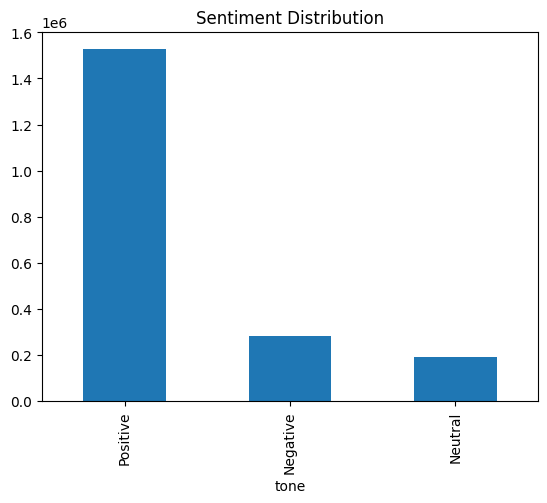

In [25]:
import matplotlib.pyplot as plt

df2['tone'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

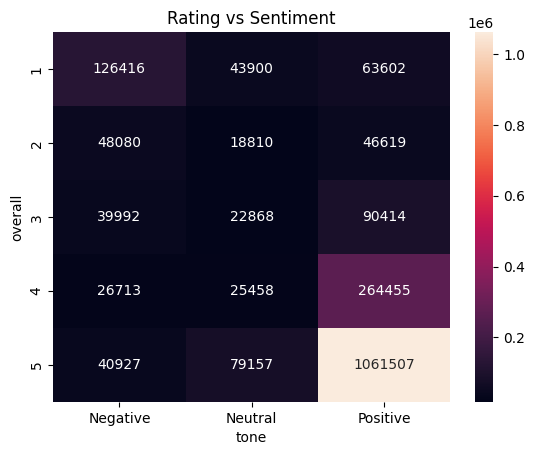

In [26]:
import seaborn as sns

sns.heatmap(pd.crosstab(df2['overall'], df2['tone']), annot=True, fmt='d')
plt.title("Rating vs Sentiment")
plt.show()

In [28]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1998918 entries, 0 to 2231654
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   overall          int64  
 1   asin             object 
 2   reviewText       object 
 3   unixReviewTime   int64  
 4   vote             int64  
 5   sentiment_score  float64
 6   review_len       int64  
 7   tone             object 
dtypes: float64(1), int64(4), object(3)
memory usage: 137.3+ MB


In [29]:
def is_conflict(row):
    rating = row['overall']
    sentiment = row['sentiment_score']
    
    if rating >= 4 and sentiment < -0.2:
        return True
    if rating <= 2 and sentiment > 0.2:
        return True
    return False

df2['conflict'] = df2.apply(is_conflict, axis=1)

In [30]:
conflict_ratio = df2['conflict'].mean()
print(f"Conflict %: {conflict_ratio * 100:.2f}%")

Conflict %: 7.74%


In [31]:
df2.groupby(['overall', 'tone']).size()

overall  tone    
1        Negative     126416
         Neutral       43900
         Positive      63602
2        Negative      48080
         Neutral       18810
         Positive      46619
3        Negative      39992
         Neutral       22868
         Positive      90414
4        Negative      26713
         Neutral       25458
         Positive     264455
5        Negative      40927
         Neutral       79157
         Positive    1061507
dtype: int64

In [32]:
df_clean = df2[~df2['conflict']]
df_conflict = df2[df2['conflict']]

print(df_clean.head())
print(df_conflict.head())


   overall        asin  \
0        4  B00000J3II   
1        5  B00000K2YR   
2        5  B00004Z5PY   
4        1  B00001W0EQ   
5        3  B00000JD34   

                                                                                                                                                                                                                                                                                                                                                                                                                                                     reviewText  \
0                                                                                                                                                                                                                                                                                                                                                                                                       

In [33]:
pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [34]:
from transformers import pipeline

bert_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0  # IMPORTANT → use GPU
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [35]:
texts = df_conflict['reviewText'].astype(str).str[:512].tolist()
results = bert_model(texts, batch_size=32)

In [36]:
df_conflict['bert_label'] = [r['label'] for r in results]
df_conflict['bert_score'] = [r['score'] for r in results]

/tmp/ipykernel_55/589958826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_conflict['bert_label'] = [r['label'] for r in results]
/tmp/ipykernel_55/589958826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_conflict['bert_score'] = [r['score'] for r in results]


In [37]:
df_conflict.to_csv("bert_results.csv", index=False)

In [38]:
df_conflict['bert_label'] = df_conflict['bert_label'].str.capitalize()

/tmp/ipykernel_55/725981636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_conflict['bert_label'] = df_conflict['bert_label'].str.capitalize()


In [39]:
df_conflict = df_conflict.copy()
df_clean = df_clean.copy()

In [40]:
df_conflict['final_tone'] = df_conflict['bert_label']

In [41]:
df_clean['final_tone'] = df_clean['tone']

In [42]:
df_final = pd.concat([df_clean, df_conflict], ignore_index=True)

In [43]:
df_final = df_final.sort_index()

In [44]:
print(df_final['final_tone'].value_counts())
print(df_final.shape)
df_final.info()

final_tone
Positive    1460000
Negative     348725
Neutral      190193
Name: count, dtype: int64
(1998918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998918 entries, 0 to 1998917
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   overall          int64  
 1   asin             object 
 2   reviewText       object 
 3   unixReviewTime   int64  
 4   vote             int64  
 5   sentiment_score  float64
 6   review_len       int64  
 7   tone             object 
 8   conflict         bool   
 9   final_tone       object 
 10  bert_label       object 
 11  bert_score       float64
dtypes: bool(1), float64(2), int64(4), object(5)
memory usage: 169.7+ MB


In [45]:
df2['tone'].value_counts()

tone
Positive    1526597
Negative     282128
Neutral      190193
Name: count, dtype: int64

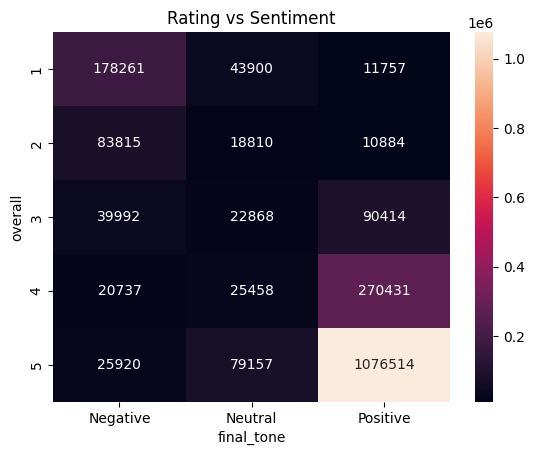

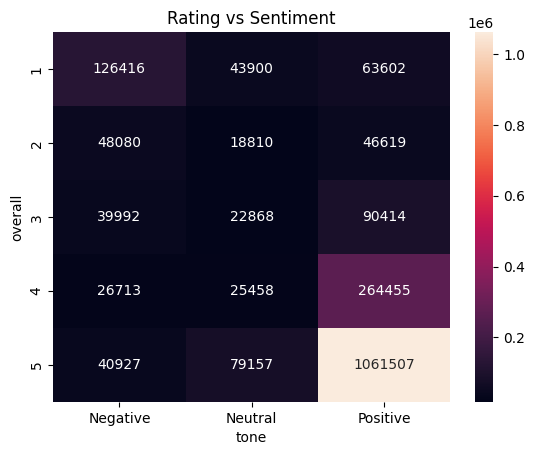

In [46]:
import seaborn as sns

# sns.heatmap(pd.crosstab(df_final['overall'], df_final['final_tone']), annot=True, fmt='d')
# plt.title("Rating vs Sentiment")
# plt.show()

sns.heatmap(pd.crosstab(df2['overall'], df2['tone']), annot=True, fmt='d')
plt.title("Rating vs Sentiment")
plt.show()

In [49]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils import resample


🧹 Starting data filtering...
✅ Filtered & Balanced Dataset Shape: (499809, 13)


In [60]:
# ==========================================
# 1. ADVANCED FILTERING (UPDATED WITH RATING LOGIC)
# ==========================================
print("Starting advanced data filtering...")

df = df_final.copy()

# A. Length Filter
df['word_count'] = df['reviewText'].fillna('').apply(lambda x: len(str(x).split()))
df = df[(df['word_count'] >= 5) & (df['word_count'] <= 300)]

# B. Confidence Filter
if 'bert_score' in df.columns:
    df['bert_score'] = df['bert_score'].fillna(1.0)
    df = df[df['bert_score'] >= 0.85]

# C. **NEW: Rating-Based Sentiment Filtering**
# We remove rows that confuse the model. 
# A 1 or 2-star review shouldn't be training the model on what "Neutral" looks like.
df = df[~((df['overall'] <= 2) & (df['final_tone'] == 'Neutral'))]
# A 4 or 5-star review shouldn't be "Neutral" either.
df = df[~((df['overall'] >= 4) & (df['final_tone'] == 'Neutral'))]

# D. Class Balancing 
min_class_size = df['final_tone'].value_counts().min()

df_balanced = pd.concat([
    resample(df[df['final_tone'] == 'Positive'], replace=False, n_samples=min_class_size, random_state=42),
    resample(df[df['final_tone'] == 'Negative'], replace=False, n_samples=min_class_size, random_state=42),
    resample(df[df['final_tone'] == 'Neutral'], replace=False, n_samples=min_class_size, random_state=42)
])

print(f"Filtered & Balanced Dataset Shape: {df_balanced.shape}")

print(" Vectorizing text data (TF-IDF without dropping crucial words)...")

label_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df_balanced['target'] = df_balanced['final_tone'].map(label_mapping)

X = df_balanced['reviewText'].astype(str)
y = df_balanced['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# THE FIX: We removed stop_words='english'. 
# Now the model will actually read the word "not" and form the bigram "not bad".
# We also added sublinear_tf=True which prevents super common words from overpowering the score.
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

🧹 Starting advanced data filtering...
✅ Filtered & Balanced Dataset Shape: (62319, 13)
🔠 Vectorizing text data (TF-IDF without dropping crucial words)...


In [61]:
# ==========================================
# 3. MODEL TRAINING & EVALUATION
# ==========================================
target_names = ['Negative', 'Neutral', 'Positive']

# --- Decision Tree ---
print("\n Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)
dt_model.fit(X_train_vec, y_train)
dt_preds = dt_model.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(classification_report(y_test, dt_preds, target_names=target_names))




🌲 Training Decision Tree...
Accuracy: 0.6591
              precision    recall  f1-score   support

    Negative       0.61      0.58      0.60      4154
     Neutral       0.60      0.70      0.65      4155
    Positive       0.78      0.70      0.74      4155

    accuracy                           0.66     12464
   macro avg       0.67      0.66      0.66     12464
weighted avg       0.67      0.66      0.66     12464



In [62]:
# --- Random Forest ---
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
rf_model.fit(X_train_vec, y_train)
rf_preds = rf_model.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds, target_names=target_names))




🌳 Training Random Forest...
Accuracy: 0.7080
              precision    recall  f1-score   support

    Negative       0.69      0.64      0.66      4154
     Neutral       0.64      0.73      0.68      4155
    Positive       0.82      0.76      0.79      4155

    accuracy                           0.71     12464
   macro avg       0.71      0.71      0.71     12464
weighted avg       0.71      0.71      0.71     12464



In [63]:
# --- LightGBM ---
print("\n Training LightGBM...")
# LightGBM handles sparse matrices natively, but we ensure it's formatted right
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=15, random_state=42, n_jobs=-1)
lgb_model.fit(X_train_vec, y_train)
lgb_preds = lgb_model.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, lgb_preds):.4f}")
print(classification_report(y_test, lgb_preds, target_names=target_names))


⚡ Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.438576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 518510
[LightGBM] [Info] Number of data points in the train set: 49855, number of used features: 9998
[LightGBM] [Info] Start training from score -1.098572
[LightGBM] [Info] Start training from score -1.098632
[LightGBM] [Info] Start training from score -1.098632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.7827
              precision    recall  f1-score   support

    Negative       0.75      0.73      0.74      4154
     Neutral       0.74      0.76      0.75      4155
    Positive       0.85      0.86      0.86      4155

    accuracy                           0.78     12464
   macro avg       0.78      0.78      0.78     12464
weighted avg       0.78      0.78      0.78     12464



In [67]:
import lightgbm as lgb

print("Training LightGBM on the new N-Gram data (this might take a few seconds)...")

# 1. Initialize and FIT the model (This fixes the NotFittedError!)
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=15, random_state=42, n_jobs=-1)
lgb_model.fit(X_train_vec, y_train)

print(" Model trained successfully!\n")
print("-" * 40)

# 2. Define the test function
def test_custom_review(review_text):
    reverse_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    
    # Vectorize the text
    text_vectorized = vectorizer.transform([review_text])
    
    # Predict
    prediction_num = lgb_model.predict(text_vectorized)[0]
    
    # Get Confidence
    probabilities = lgb_model.predict_proba(text_vectorized)[0]
    confidence = probabilities[prediction_num] * 100
    
    predicted_tone = reverse_mapping[prediction_num]
    
    print(f"Review: '{review_text}'")
    print(f"Predicted Sentiment: {predicted_tone}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 40)

# 3. Run the tests!
test_custom_review("The picture quality is amazing, but the remote control feels super cheap.")
test_custom_review("I plugged it in and it immediately caught on fire. Do not buy!")
test_custom_review("The cable is 3 feet long and black.")
test_custom_review("Absolutely fantastic product, highly recommend it to everyone.")
test_custom_review("The product is too good for its rating.")
test_custom_review("Not bad, worth money.")
test_custom_review("Not good, waste of time.")
test_custom_review("Not good")
test_custom_review("Not bad")


⚡ Training LightGBM on the new N-Gram data (this might take a few seconds)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 3.366802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 518510
[LightGBM] [Info] Number of data points in the train set: 49855, number of used features: 9998
[LightGBM] [Info] Start training from score -1.098572
[LightGBM] [Info] Start training from score -1.098632
[LightGBM] [Info] Start training from score -1.098632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
✅ Model trained successfully!

----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Review: 'The picture quality is amazing, but the remote control feels super cheap.'
Predicted Sentiment: Positive
Confidence: 69.53%
----------------------------------------
Review: 'I plugged it in and it immediately caught on fire. Do not buy!'
Predicted Sentiment: Negative
Confidence: 86.75%
----------------------------------------
Review: 'The cable is 3 feet long and black.'
Predicted Sentiment: Neutral
Confidence: 79.04%
----------------------------------------
Review: 'Absolutely fantastic product, highly recommend it to everyone.'
Predicted Sentiment: Positive
Confidence: 97.99%
----------------------------------------
Review: 'The product is too good for its rating.'
Predicted Sentiment: Neutral
Confidence: 52.08%
----------------------------------------
Review: 'Not bad, worth money.'
Predicted Sentiment: Positive
Confidence: 41.18%
----------------------------------------
Review: 'Not good, waste of time.'
Predicted Sentiment: Negative
Confidence: 97.18%
--------------------

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [73]:
import joblib

# Save the LightGBM Sentiment Model and the TF-IDF Vectorizer
print("Saving Sentiment Model and Vectorizer...")
joblib.dump(lgb_model, 'sentiment_lgb_model.joblib')
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')
print("Saved successfully!")

Saving Sentiment Model and Vectorizer...
Saved successfully!


🔍 Starting LightGBM EDA...


/tmp/ipykernel_55/3650695434.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Word', data=df_lgb_importance.head(20), palette='viridis')


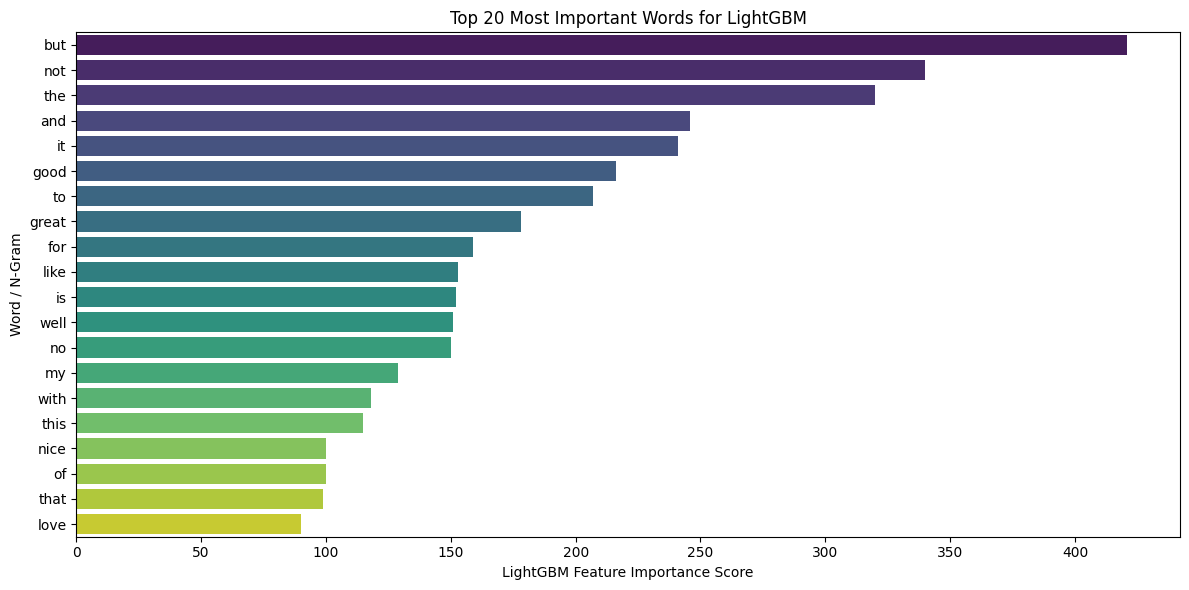

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


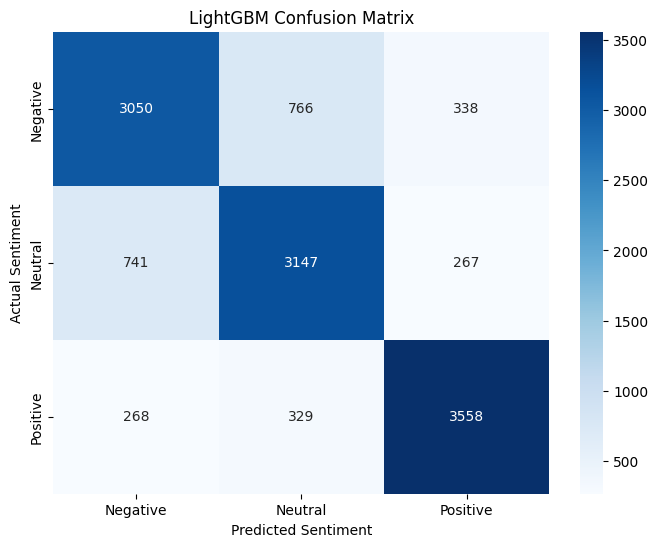

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

print(" Starting LightGBM EDA...")

# ==========================================
# A. Feature Importance (Top Words)
# ==========================================
# 1. Get the actual words from your TF-IDF Vectorizer
feature_names = vectorizer.get_feature_names_out()

# 2. Get the importance scores from LightGBM (how much it used each word)
lgb_importances = lgb_model.feature_importances_

# 3. Create a DataFrame to sort and visualize them
df_lgb_importance = pd.DataFrame({
    'Word': feature_names,
    'Importance': lgb_importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the top 20 most important words
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Word', data=df_lgb_importance.head(20), palette='viridis')
plt.title('Top 20 Most Important Words for LightGBM')
plt.xlabel('LightGBM Feature Importance Score')
plt.ylabel('Word / N-Gram')
plt.tight_layout()
plt.show()

# ==========================================
# B. Confusion Matrix Visualization
# ==========================================
# 1. Get predictions on the test set
lgb_preds = lgb_model.predict(X_test_vec)

# 2. Calculate the confusion matrix
cm_lgb = confusion_matrix(y_test, lgb_preds)

# 3. Plot it using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('LightGBM Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

In [65]:
from sklearn.ensemble import VotingClassifier

print("Training Ensemble (LightGBM + Random Forest)...")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=15, random_state=42, n_jobs=-1)

ensemble_model = VotingClassifier(
    estimators=[('RandomForest', rf_model), ('LightGBM', lgb_model)],
    voting='soft',
    n_jobs=-1
)

ensemble_model.fit(X_train_vec, y_train)

ensemble_preds = ensemble_model.predict(X_test_vec)
print(f"Ensemble Accuracy: {accuracy_score(y_test, ensemble_preds):.4f}")
print(classification_report(y_test, ensemble_preds, target_names=target_names))

🤝 Training Ensemble (LightGBM + Random Forest)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble Accuracy: 0.7788
              precision    recall  f1-score   support

    Negative       0.75      0.73      0.74      4154
     Neutral       0.74      0.75      0.75      4155
    Positive       0.85      0.85      0.85      4155

    accuracy                           0.78     12464
   macro avg       0.78      0.78      0.78     12464
weighted avg       0.78      0.78      0.78     12464

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.388182 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 518510
[LightGBM] [Info] Number of data points in the train set: 49855, number of used features: 9998
[LightGBM] [Info] Start training from score -1.098572
[LightGBM] [Info] Start training from score -1.098632
[LightGBM] [Info] Start training from score -1.098632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [69]:
def test_ensemble_review(review_text):
    reverse_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    
    text_vectorized = vectorizer.transform([review_text])
    
    prediction_num = ensemble_model.predict(text_vectorized)[0]
    
    probabilities = ensemble_model.predict_proba(text_vectorized)[0]
    confidence = probabilities[prediction_num] * 100
    
    predicted_tone = reverse_mapping[prediction_num]
    
    print(f"Review: '{review_text}'")
    print(f"Predicted Sentiment: {predicted_tone}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 40)

test_ensemble_review("The picture quality is amazing, but the remote control feels super cheap.")
test_ensemble_review("I plugged it in and it immediately caught on fire. Do not buy!")
test_ensemble_review("The cable is 3 feet long and black.")
test_ensemble_review("Absolutely fantastic product, highly recommend it to everyone.")
test_ensemble_review("The product is too good for its rating.")
test_ensemble_review("Not bad, worth money.")
test_ensemble_review("Not good, waste of time.")
test_ensemble_review("Not good")
test_ensemble_review("Not bad")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Review: 'The picture quality is amazing, but the remote control feels super cheap.'
Predicted Sentiment: Positive
Confidence: 52.04%
----------------------------------------
Review: 'I plugged it in and it immediately caught on fire. Do not buy!'
Predicted Sentiment: Negative
Confidence: 68.05%
----------------------------------------
Review: 'The cable is 3 feet long and black.'
Predicted Sentiment: Neutral
Confidence: 59.73%
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Review: 'Absolutely fantastic product, highly recommend it to everyone.'
Predicted Sentiment: Positive
Confidence: 71.17%
----------------------------------------
Review: 'The product is too good for its rating.'
Predicted Sentiment: Neutral
Confidence: 45.98%
----------------------------------------
Review: 'Not bad, worth money.'
Predicted Sentiment: Neutral
Confidence: 34.41%
----------------------------------------
Review: 'Not good, waste of time.'
Predicted Sentiment: Negative
Confidence: 70.95%
----------------------------------------
Review: 'Not good'
Predicted Sentiment: Negative
Confidence: 52.71%
----------------------------------------
Review: 'Not bad'
Predicted Sentiment: Neutral
Confidence: 56.06%
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [75]:
import joblib

print("Saving Ensemble Model and Vectorizer...")

joblib.dump(ensemble_model, 'sentiment_ensemble_model.joblib')

joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')

print("Saved successfully!")

📦 Saving Ensemble Model and Vectorizer...
✅ Saved successfully!


In [76]:
from IPython.display import FileLink

display(FileLink('sentiment_ensemble_model.joblib'))

display(FileLink('tfidf_vectorizer.joblib'))

/kaggle/working/sentiment_ensemble_model.joblib

/kaggle/working/tfidf_vectorizer.joblib

🤝 Starting Ensemble Model EDA...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


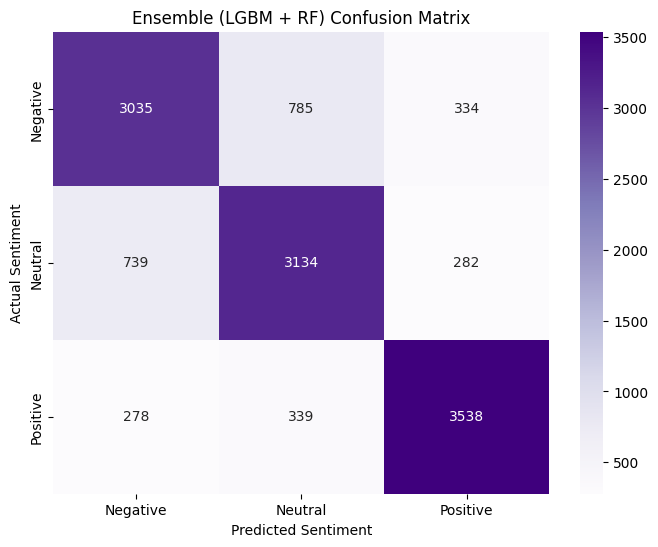

/tmp/ipykernel_55/1860091032.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Word', data=df_rf_importance.head(20), palette='magma')


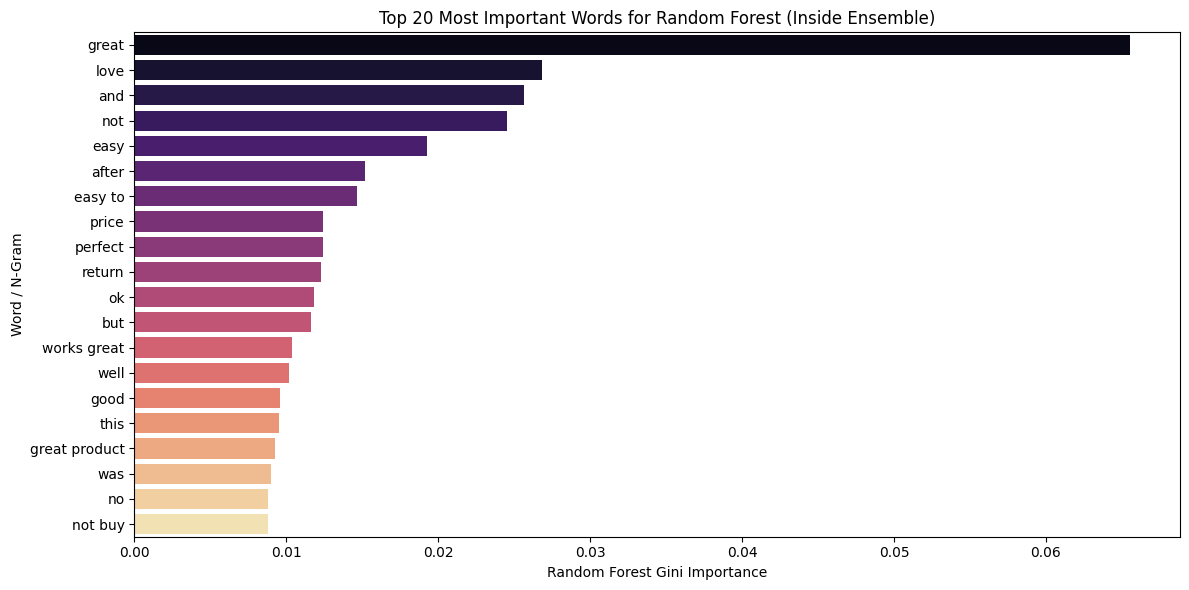

In [78]:
print(" Starting Ensemble Model EDA...")

# ==========================================
# A. Ensemble Confusion Matrix
# ==========================================
# 1. Get predictions from the combined ensemble
ensemble_preds = ensemble_model.predict(X_test_vec)

# 2. Calculate and plot the confusion matrix
cm_ensemble = confusion_matrix(y_test, ensemble_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Ensemble (LGBM + RF) Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

# ==========================================
# B. Random Forest Feature Importance (Inside the Ensemble)
# ==========================================
# 1. Extract the trained Random Forest model from the VotingClassifier
# The models are stored in the 'estimators_' attribute
rf_model_extracted = ensemble_model.estimators_[0] 

# 2. Get the importance scores from the Random Forest
rf_importances = rf_model_extracted.feature_importances_

# 3. Create a DataFrame
df_rf_importance = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(),
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot the top 20 words for Random Forest
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Word', data=df_rf_importance.head(20), palette='magma')
plt.title('Top 20 Most Important Words for Random Forest (Inside Ensemble)')
plt.xlabel('Random Forest Gini Importance')
plt.ylabel('Word / N-Gram')
plt.tight_layout()
plt.show()

In [71]:
import numpy as np

def get_bert_probabilities(text):
    """
    Runs text through BERT and formats the output into a 3-class probability array:
    [P(Negative), P(Neutral), P(Positive)]
    """
    # Truncate text to 512 tokens to prevent BERT from crashing on long reviews
    result = bert_model(text, truncation=True, max_length=512)[0]
    label = result['label']
    score = result['score']
    
    # Initialize [Negative, Neutral, Positive]
    bert_probs = np.array([0.0, 0.0, 0.0])
    
    # Map BERT's 2-class output to our 3-class system
    if label == 'POSITIVE':
        bert_probs[2] = score          # High probability for Positive
        bert_probs[0] = 1.0 - score    # Remainder goes to Negative
    else:
        bert_probs[0] = score          # High probability for Negative
        bert_probs[2] = 1.0 - score    # Remainder goes to Positive
        
    return bert_probs

def test_hybrid_ensemble(review_text, lgb_weight=0.5, bert_weight=0.5):
    """
    Combines LightGBM and BERT using a weighted soft-voting strategy.
    """
    reverse_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    
    # 1. Get LightGBM Probabilities
    text_vectorized = vectorizer.transform([review_text])
    lgb_probs = lgb_model.predict_proba(text_vectorized)[0]
    
    # 2. Get BERT Probabilities
    bert_probs = get_bert_probabilities(review_text)
    
    # 3. Calculate Weighted Average
    # This combines the "brains" of both models based on the weights you set
    final_probs = (lgb_probs * lgb_weight) + (bert_probs * bert_weight)
    
    # 4. Determine Final Winner
    prediction_num = np.argmax(final_probs)
    final_confidence = final_probs[prediction_num] * 100
    predicted_tone = reverse_mapping[prediction_num]
    
    # 5. Output formatted results
    print(f" Review: '{review_text}'")
    print("-" * 50)
    print(f" LightGBM thought: {reverse_mapping[np.argmax(lgb_probs)]} ({np.max(lgb_probs)*100:.1f}%)")
    print(f" BERT thought:     {reverse_mapping[np.argmax(bert_probs)]} ({np.max(bert_probs)*100:.1f}%)")
    print("-" * 50)
    print(f" FINAL PREDICTION: {predicted_tone} (Confidence: {final_confidence:.1f}%)")
    print("\n")

test_hybrid_ensemble("I plugged it in and it immediately caught on fire. Do not buy!", lgb_weight=0.4, bert_weight=0.6)
test_hybrid_ensemble("Not bad, worth money.", lgb_weight=0.4, bert_weight=0.6)
test_hybrid_ensemble("The cable is exactly 3 feet long.", lgb_weight=0.7, bert_weight=0.3)
test_hybrid_ensemble("The picture quality is amazing, but the remote control feels super cheap.")
test_hybrid_ensemble("I plugged it in and it immediately caught on fire. Do not buy!")
test_hybrid_ensemble("The cable is 3 feet long and black.")
test_hybrid_ensemble("Absolutely fantastic product, highly recommend it to everyone.")
test_hybrid_ensemble("The product is too good for its rating.")
test_hybrid_ensemble("Not bad, worth money.")
test_hybrid_ensemble("Not good, waste of time.")
test_hybrid_ensemble("Not good")
test_hybrid_ensemble("Not bad")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


📝 Review: 'I plugged it in and it immediately caught on fire. Do not buy!'
--------------------------------------------------
🌲 LightGBM thought: Negative (86.8%)
🤖 BERT thought:     Negative (99.9%)
--------------------------------------------------
🎯 FINAL PREDICTION: Negative (Confidence: 94.6%)


📝 Review: 'Not bad, worth money.'
--------------------------------------------------
🌲 LightGBM thought: Positive (41.2%)
🤖 BERT thought:     Positive (99.9%)
--------------------------------------------------
🎯 FINAL PREDICTION: Positive (Confidence: 76.4%)


📝 Review: 'The cable is exactly 3 feet long.'
--------------------------------------------------
🌲 LightGBM thought: Neutral (82.2%)
🤖 BERT thought:     Negative (72.7%)
--------------------------------------------------
🎯 FINAL PREDICTION: Neutral (Confidence: 57.5%)


📝 Review: 'The picture quality is amazing, but the remote control feels super cheap.'
--------------------------------------------------
🌲 LightGBM thought: Positive 

# Part 1: Dataset & Text EDA (Run this first)

EDA: Rating vs. Review Length

📏 Analyzing Rating vs. Review Length...


/tmp/ipykernel_55/3079759116.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='overall', y='word_count', data=df_balanced, palette='coolwarm')
/tmp/ipykernel_55/3079759116.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='overall', y='word_count', data=avg_length, palette='coolwarm')


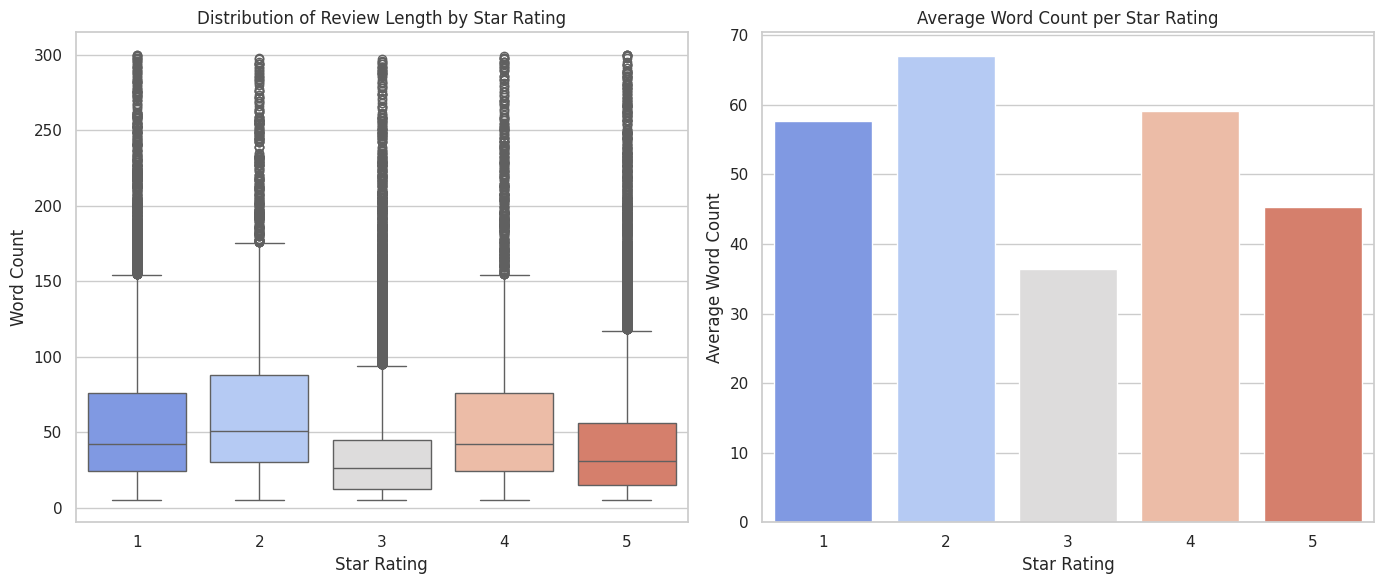

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Analyzing Rating vs. Review Length...")

# Ensure word_count exists
if 'word_count' not in df_balanced.columns:
    df_balanced['word_count'] = df_balanced['reviewText'].fillna('').apply(lambda x: len(str(x).split()))

plt.figure(figsize=(14, 6))

# Plot A: Boxplot to show distribution and outliers
plt.subplot(1, 2, 1)
sns.boxplot(x='overall', y='word_count', data=df_balanced, palette='coolwarm')
plt.title('Distribution of Review Length by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Word Count')

# Plot B: Barplot to show the average word count per rating
plt.subplot(1, 2, 2)
avg_length = df_balanced.groupby('overall')['word_count'].mean().reset_index()
sns.barplot(x='overall', y='word_count', data=avg_length, palette='coolwarm')
plt.title('Average Word Count per Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Word Count')

plt.tight_layout()
plt.show()

2. EDA: Rating vs. Sentiment

🎭 Analyzing Rating vs. Sentiment...


/tmp/ipykernel_55/1137163506.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='overall', y='sentiment_score', data=df_balanced, palette='Spectral')


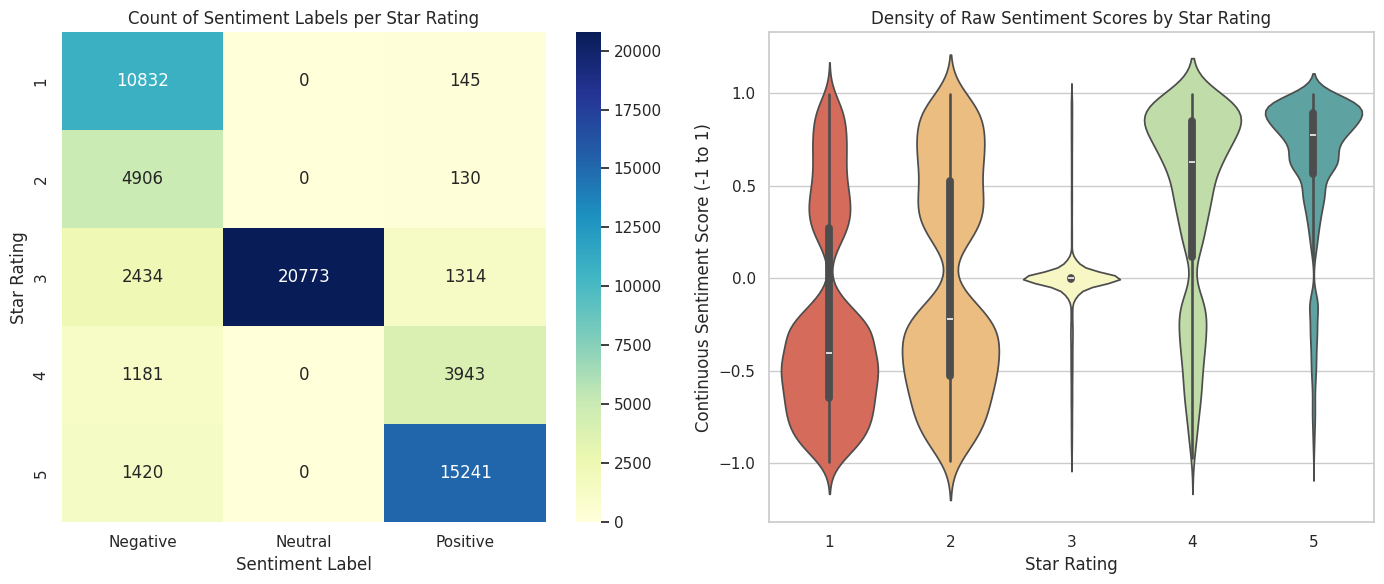

In [83]:
print("Analyzing Rating vs. Sentiment...")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
crosstab_data = pd.crosstab(df_balanced['overall'], df_balanced['final_tone'])
sns.heatmap(crosstab_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Count of Sentiment Labels per Star Rating')
plt.xlabel('Sentiment Label')
plt.ylabel('Star Rating')

plt.subplot(1, 2, 2)
if 'sentiment_score' in df_balanced.columns:
    sns.violinplot(x='overall', y='sentiment_score', data=df_balanced, palette='Spectral')
    plt.title('Density of Raw Sentiment Scores by Star Rating')
    plt.xlabel('Star Rating')
    plt.ylabel('Continuous Sentiment Score (-1 to 1)')
else:
    plt.text(0.5, 0.5, 'Raw sentiment_score column not found.', 
             horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

📊 Starting General Dataset EDA...


/tmp/ipykernel_55/560984185.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='final_tone', data=df_balanced, palette='Set2')


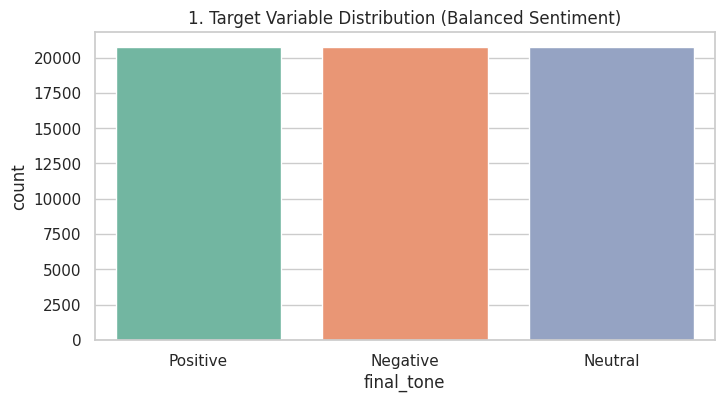

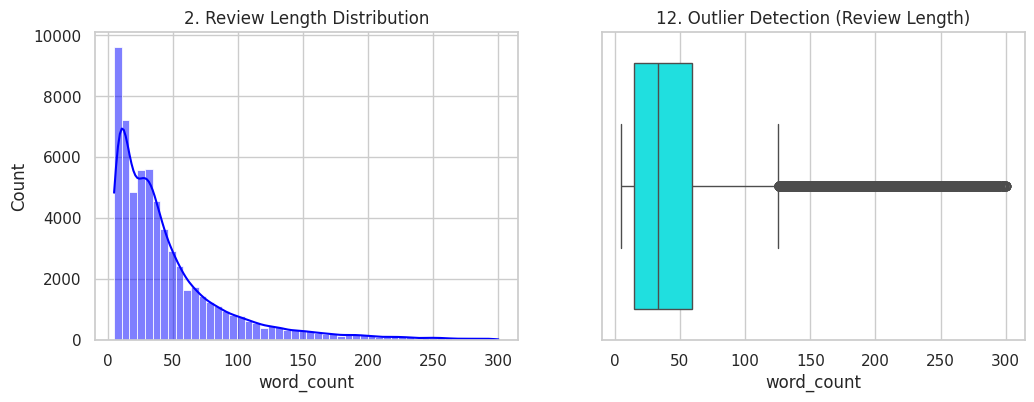

/tmp/ipykernel_55/560984185.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='overall', y='word_count', data=df_balanced, palette='coolwarm')


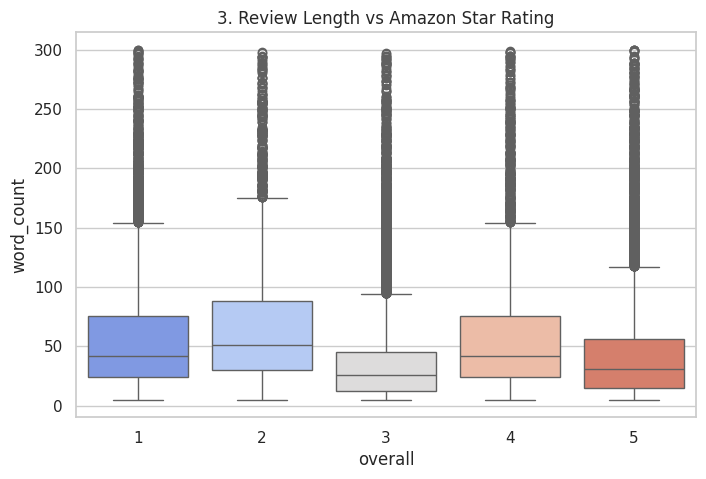

/tmp/ipykernel_55/560984185.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=freq_df.head(15), palette='viridis')


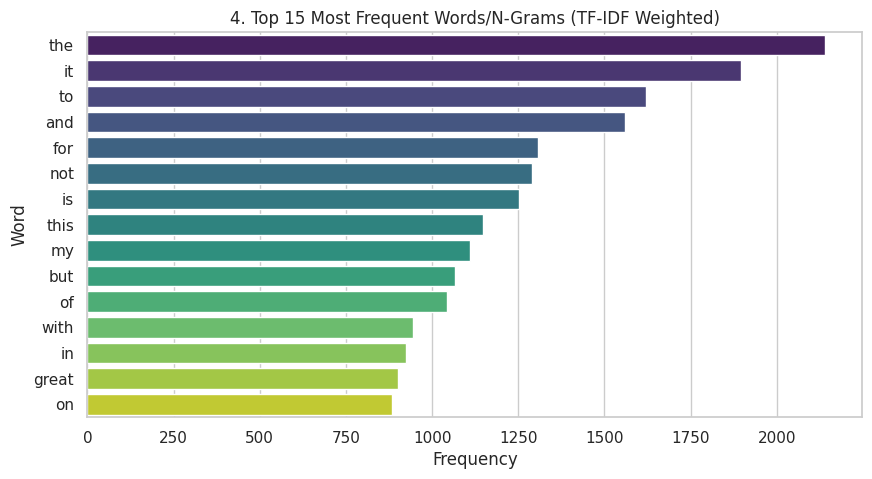

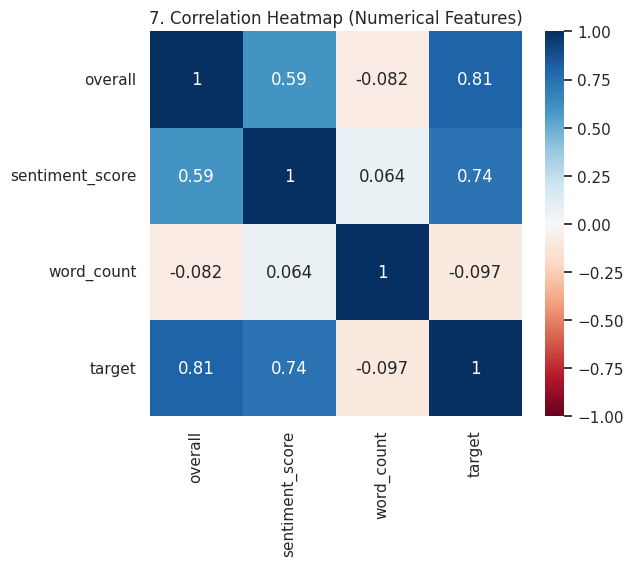

/tmp/ipykernel_55/560984185.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


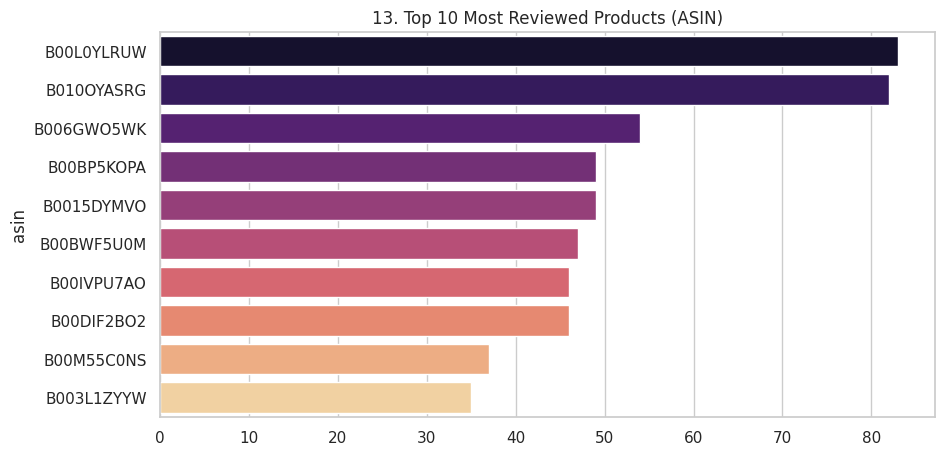

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Starting General Dataset EDA...")
sns.set_theme(style="whitegrid")

# 1. Target Variable Distribution (Sentiment)
plt.figure(figsize=(8, 4))
sns.countplot(x='final_tone', data=df_balanced, palette='Set2')
plt.title('1. Target Variable Distribution (Balanced Sentiment)')
plt.show()

# 2 & 12. Review Length Analysis & Outlier Detection
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_balanced['word_count'], bins=50, kde=True, color='blue')
plt.title('2. Review Length Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_balanced['word_count'], color='cyan')
plt.title('12. Outlier Detection (Review Length)')
plt.show()

# 3. Review Length vs Rating
plt.figure(figsize=(8, 5))
sns.boxplot(x='overall', y='word_count', data=df_balanced, palette='coolwarm')
plt.title('3. Review Length vs Amazon Star Rating')
plt.show()

# 4. Word Frequency (Top Words from TF-IDF)
# Summing up the TF-IDF scores across all documents in the training set
word_frequencies = np.array(X_train_vec.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()
freq_df = pd.DataFrame({'Word': words, 'Frequency': word_frequencies}).sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Word', data=freq_df.head(15), palette='viridis')
plt.title('4. Top 15 Most Frequent Words/N-Grams (TF-IDF Weighted)')
plt.show()

# 5 & 7. Sentiment Polarity Check & Correlation Heatmap
# Assuming 'sentiment_score' (VADER) and 'overall' (Stars) are still in df_balanced
plt.figure(figsize=(6, 5))
corr_cols = ['overall', 'sentiment_score', 'word_count', 'target']
sns.heatmap(df_balanced[corr_cols].corr(), annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title('7. Correlation Heatmap (Numerical Features)')
plt.show()

# 13. Product-wise Analysis (Top 10 Most Reviewed Products)
if 'asin' in df_balanced.columns:
    plt.figure(figsize=(10, 5))
    top_products = df_balanced['asin'].value_counts().head(10)
    sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
    plt.title('13. Top 10 Most Reviewed Products (ASIN)')
    plt.show()

Part 2: LightGBM Specific EDA

⚡ Starting LightGBM Specific EDA...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


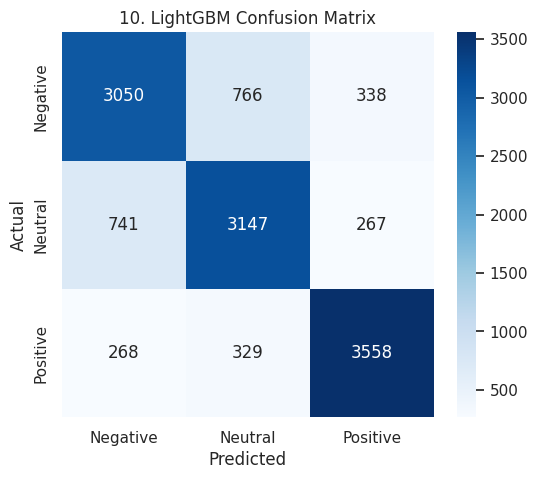

/tmp/ipykernel_55/301016136.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Word', data=lgb_importance.head(15), palette='Blues_r')


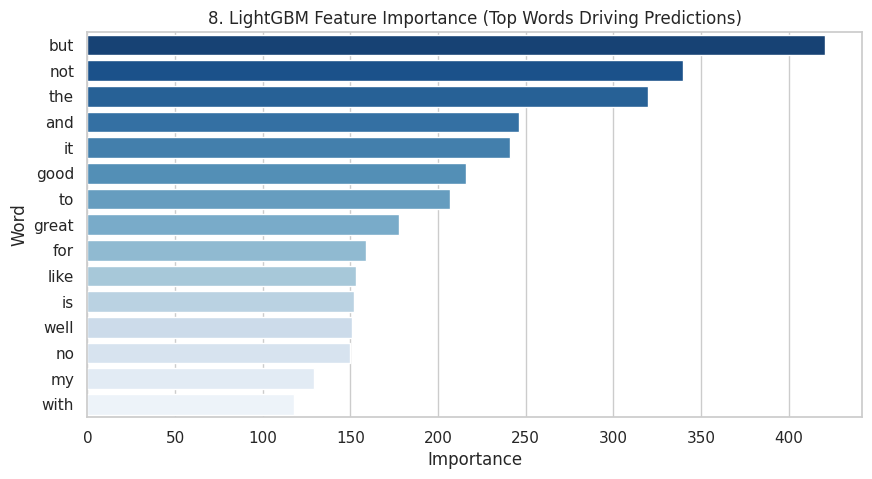

/tmp/ipykernel_55/301016136.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_length_lgb = test_results_lgb.groupby('Length_Category')['Correct'].mean() * 100
/tmp/ipykernel_55/301016136.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracy_by_length_lgb.index, y=accuracy_by_length_lgb.values, palette='crest')


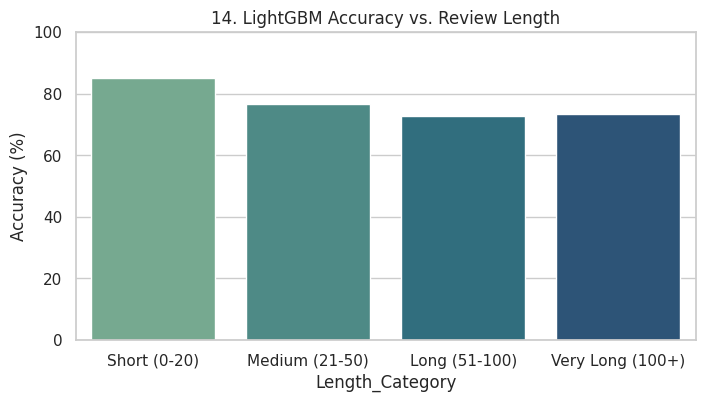

In [80]:
from sklearn.metrics import confusion_matrix

print(" Starting LightGBM Specific EDA...")

# Get Predictions
lgb_preds = lgb_model.predict(X_test_vec)

# 10. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, lgb_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('10. LightGBM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8 & 11. Feature Importance (Review Words vs Sentiment)
lgb_importance = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(),
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Word', data=lgb_importance.head(15), palette='Blues_r')
plt.title('8. LightGBM Feature Importance (Top Words Driving Predictions)')
plt.show()

# 9 & 14. Prediction Error & Short vs Long Reviews Accuracy
# Create a DataFrame of the test set to analyze where the model failed
test_results_lgb = pd.DataFrame({
    'Review': X_test.values,
    'True_Label': y_test.values,
    'Predicted_Label': lgb_preds,
    'Length': X_test.apply(lambda x: len(str(x).split())).values
})

test_results_lgb['Correct'] = test_results_lgb['True_Label'] == test_results_lgb['Predicted_Label']

# Categorize lengths
test_results_lgb['Length_Category'] = pd.cut(test_results_lgb['Length'], 
                                             bins=[0, 20, 50, 100, 300], 
                                             labels=['Short (0-20)', 'Medium (21-50)', 'Long (51-100)', 'Very Long (100+)'])

accuracy_by_length_lgb = test_results_lgb.groupby('Length_Category')['Correct'].mean() * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=accuracy_by_length_lgb.index, y=accuracy_by_length_lgb.values, palette='crest')
plt.title('14. LightGBM Accuracy vs. Review Length')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.show()

Part 3: Ensemble (LightGBM + Random Forest) Specific EDA

🤝 Starting Ensemble Model Specific EDA...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


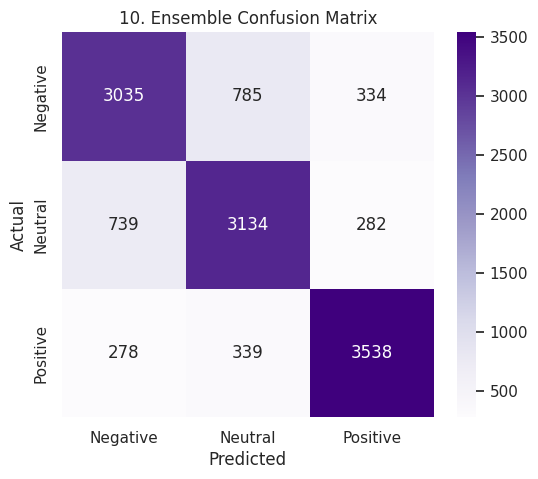

/tmp/ipykernel_55/1365269805.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Word', data=rf_importance.head(15), palette='Purples_r')


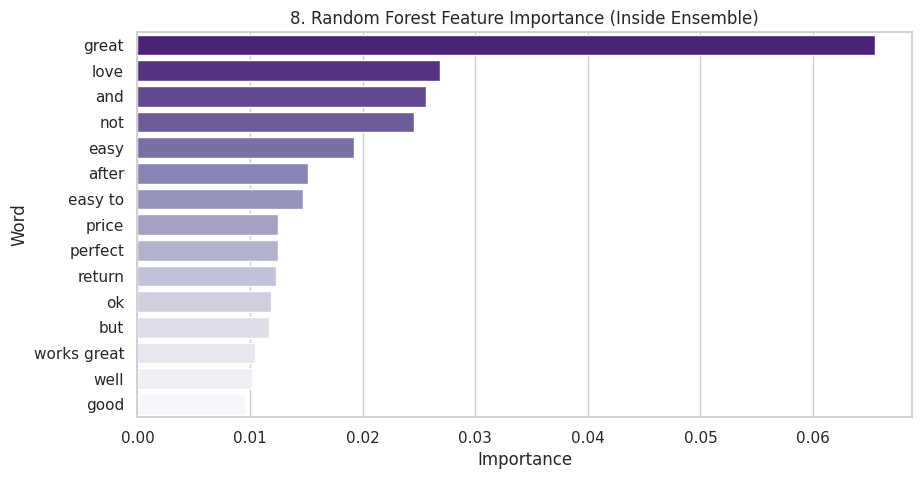

/tmp/ipykernel_55/1365269805.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_length_ens = test_results_ens.groupby('Length_Category')['Correct'].mean() * 100
/tmp/ipykernel_55/1365269805.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracy_by_length_ens.index, y=accuracy_by_length_ens.values, palette='flare')


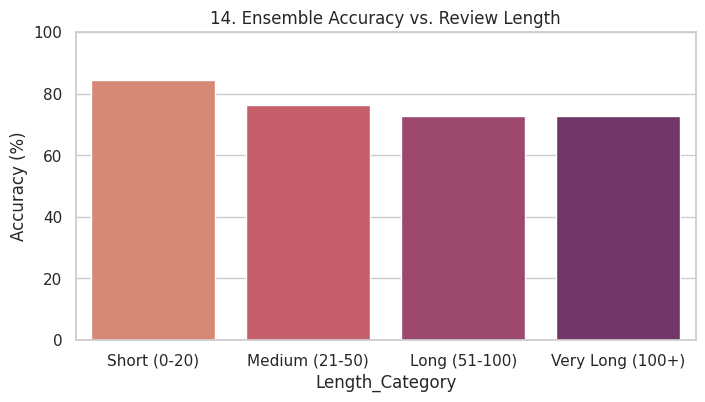

In [81]:
print(" Starting Ensemble Model Specific EDA...")

# Get Predictions
ensemble_preds = ensemble_model.predict(X_test_vec)

# 10. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, ensemble_preds), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Neutral', 'Positive'], 
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('10. Ensemble Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8. Feature Importance (Extracting the Random Forest from the Ensemble)
rf_model_extracted = ensemble_model.estimators_[0] 
rf_importance = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(),
    'Importance': rf_model_extracted.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Word', data=rf_importance.head(15), palette='Purples_r')
plt.title('8. Random Forest Feature Importance (Inside Ensemble)')
plt.show()

# 9 & 14. Prediction Error & Short vs Long Reviews Accuracy
test_results_ens = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': ensemble_preds,
    'Length': X_test.apply(lambda x: len(str(x).split())).values
})

test_results_ens['Correct'] = test_results_ens['True_Label'] == test_results_ens['Predicted_Label']
test_results_ens['Length_Category'] = pd.cut(test_results_ens['Length'], 
                                             bins=[0, 20, 50, 100, 300], 
                                             labels=['Short (0-20)', 'Medium (21-50)', 'Long (51-100)', 'Very Long (100+)'])

accuracy_by_length_ens = test_results_ens.groupby('Length_Category')['Correct'].mean() * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=accuracy_by_length_ens.index, y=accuracy_by_length_ens.values, palette='flare')
plt.title('14. Ensemble Accuracy vs. Review Length')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.show()